# **Load & Explore the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
# Load the datasets (training)
# Read Dataset from a Google Drive File
dataset_link = "https://drive.google.com/file/d/1aAvYYr4QpCWPkIMT55u3YH7w3rJ9DL1t/view?usp=sharing"

# Get the ID part of the file
id = dataset_link.split("/")[-2]

# Create a new_link using the ID to read the CSV file in Pandas
new_link = f"https://drive.google.com/uc?id={id}"
print(new_link)

train_df = pd.read_csv(new_link)

https://drive.google.com/uc?id=1aAvYYr4QpCWPkIMT55u3YH7w3rJ9DL1t


In [ ]:
# Load the datasets (testing)
# Read Dataset from a Google Drive File
dataset_link = "https://drive.google.com/file/d/1Ccqf9nYE-Xhku2nxX5b1_6BF2tLWc06t/view?usp=drive_link"

# Get the ID part of the file
id = dataset_link.split("/")[-2]

# Create a new_link using the ID to read the CSV file in Pandas
new_link = f"https://drive.google.com/uc?id={id}"
print(new_link)

test_df = pd.read_csv(new_link)

https://drive.google.com/uc?id=1Ccqf9nYE-Xhku2nxX5b1_6BF2tLWc06t


In [ ]:
# Basic info
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

Training Data Shape: (19183, 3)
Testing Data Shape: (4796, 3)


In [ ]:
# Preview the training data
print(train_df.head())

   Sentence #                                           Sentence  \
0           1  AU officials reported fresh fighting Sunday , ...   
1           2  Also Saturday , in an unrelated development , ...   
2           3  They replied , " We would willingly have helpe...   
3           4          He said he has ordered an investigation .   
4           5  World famous Russian cellist and conductor , M...   

                                                 Tag  
0  ['O', 'O', 'O', 'O', 'O', 'B-tim', 'O', 'O', '...  
1  ['O', 'B-tim', 'O', 'O', 'O', 'O', 'O', 'O', '...  
2  ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ...  
3           ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']  
4  ['O', 'O', 'B-gpe', 'O', 'O', 'O', 'O', 'B-per...  


In [ ]:
# Preview the testing data
print(test_df.head())

   Sentence #                                           Sentence  \
0           1  Former Prime Minister Ayad Allawi 's Iraqiya a...   
1           2  Venezuela 's president Hugo Chavez is an outsp...   
2           3  The heavily subsidized rates Cubans now pay fo...   
3           4  She told reporters the trip convinced her that...   
4           5  Venezuela has some of the world 's largest oil...   

                                                 Tag  
0  ['O', 'O', 'O', 'B-per', 'I-per', 'O', 'O', 'O...  
1  ['B-geo', 'O', 'O', 'B-per', 'I-per', 'O', 'O'...  
2  ['O', 'O', 'O', 'O', 'B-gpe', 'O', 'O', 'O', '...  
3  ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ge...  
4  ['B-geo', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '...  


In [ ]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19183 entries, 0 to 19182
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sentence #  19183 non-null  int64 
 1   Sentence    19183 non-null  object
 2   Tag         19183 non-null  object
dtypes: int64(1), object(2)
memory usage: 449.7+ KB
None


In [ ]:
print(train_df.describe())

         Sentence #
count  19183.000000
mean    9592.000000
std     5537.799443
min        1.000000
25%     4796.500000
50%     9592.000000
75%    14387.500000
max    19183.000000


In [ ]:
print(train_df.isnull().sum())

Sentence #    0
Sentence      0
Tag           0
dtype: int64


In [ ]:
# Count total sentences
print("\nTotal Train Sentences:", len(train_df))
print("Total Test Sentences:", len(test_df))


Total Train Sentences: 19183
Total Test Sentences: 4796


In [ ]:
# Average tokens per sentence in training data
avg_train_tokens = train_df['Sentence'].apply(lambda x: len(x.split())).mean()
print("Average Tokens per Sentence (Train):", avg_train_tokens)

Average Tokens per Sentence (Train): 21.84037950268467


In [ ]:
# Tag distribution
all_tags = train_df['Tag'].apply(eval).explode()
tag_distribution = all_tags.value_counts()
print("\nTag Distribution:\n", tag_distribution)


Tag Distribution:
 Tag
O        355120
B-geo     15057
B-org      8002
B-tim      7956
I-per      6911
B-per      6752
I-org      6548
B-gpe      6406
I-geo      2981
I-tim      2481
B-art       166
B-eve       140
I-art       137
I-eve       114
B-nat        90
I-gpe        80
I-nat        27
Name: count, dtype: int64


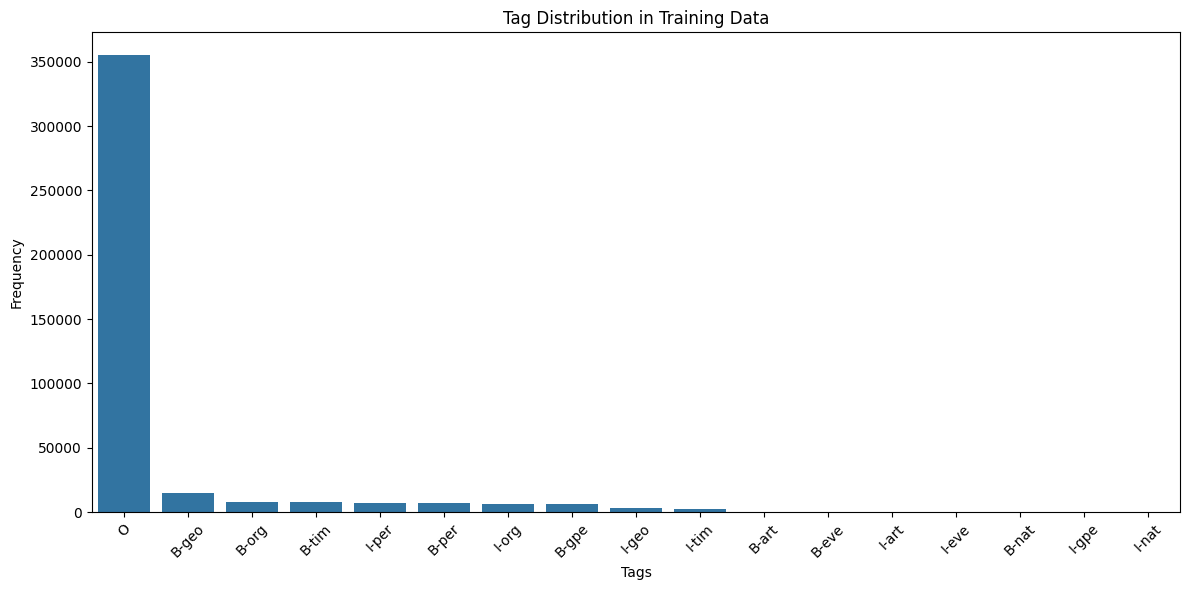

In [ ]:
# Plot tag distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=tag_distribution.index, y=tag_distribution.values)
plt.title("Tag Distribution in Training Data")
plt.xlabel("Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Basic Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [ ]:
# Helper to clean up tokens from bad formatting
def clean_token_list(s):
    return [token.strip("[],'\"") for token in s.split()]

# Convert space-separated strings to word/token lists
train_sentences = train_df["Sentence"].apply(clean_token_list).tolist()
train_tags = train_df["Tag"].apply(clean_token_list).tolist()
test_sentences = test_df["Sentence"].apply(clean_token_list).tolist()
test_tags = test_df["Tag"].apply(clean_token_list).tolist()

In [ ]:
# Build vocabulary
words = list(set(word for sentence in train_sentences for word in sentence))
tags = list(set(tag for tag_seq in train_tags for tag in tag_seq))

In [ ]:
# Index maps
word2idx = {w: i + 2 for i, w in enumerate(words)}
word2idx["PAD"] = 0
word2idx["UNK"] = 1

tag2idx = {t: i + 1 for i, t in enumerate(tags)}
tag2idx["PAD"] = 0
idx2tag = {i: t for t, i in tag2idx.items()}

In [ ]:
# Max sentence length
max_len = max(len(s) for s in train_sentences)

In [ ]:
# Function to encode and pad
def encode_and_pad(sentences, tags, word2idx, tag2idx, max_len):
    X = [[word2idx.get(w, word2idx["UNK"]) for w in s] for s in sentences]
    X = pad_sequences(X, maxlen=max_len, padding='post', value=word2idx["PAD"])

    y = [[tag2idx.get(t, tag2idx.get('O', 0)) for t in tag_seq] for tag_seq in tags]
    y = pad_sequences(y, maxlen=max_len, padding='post', value=tag2idx["PAD"])
    #y = [to_categorical(seq, num_classes=len(tag2idx)) for seq in y]

    return X, np.array(y)

# Final encoded datasets
X_train, y_train = encode_and_pad(train_sentences, train_tags, word2idx, tag2idx, max_len)
X_test, y_test = encode_and_pad(test_sentences, test_tags, word2idx, tag2idx, max_len)

In [ ]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [ ]:
# Print the shapes of the new splits
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Print summary
print("Vocabulary size:", len(word2idx))
print("Tag size:", len(tag2idx))

X_train shape: (17264, 104)
y_train shape: (17264, 104)
X_val shape: (1919, 104)
y_val shape: (1919, 104)
X_test shape: (4796, 104)
y_test shape: (4796, 104)
Vocabulary size: 22905
Tag size: 18


In [ ]:
tag2idx

{'O': 1,
 'B-per': 2,
 'I-art': 3,
 'B-org': 4,
 'I-gpe': 5,
 'I-org': 6,
 'B-tim': 7,
 'I-geo': 8,
 'I-tim': 9,
 'B-eve': 10,
 'I-eve': 11,
 'I-nat': 12,
 'B-nat': 13,
 'I-per': 14,
 'B-gpe': 15,
 'B-art': 16,
 'B-geo': 17,
 'PAD': 0}

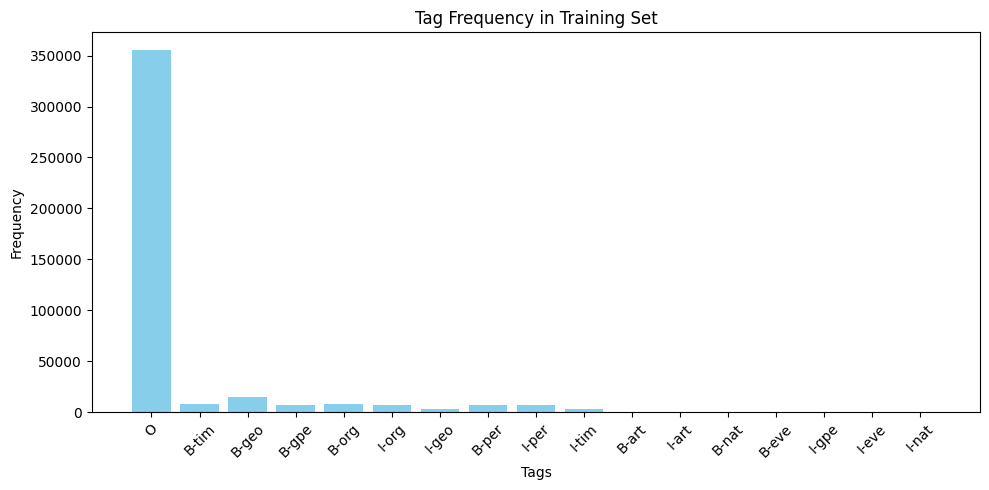

In [ ]:
# Flatten tag list and count frequencies
all_tags = [tag for seq in train_tags for tag in seq]
tag_counts = Counter(all_tags)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(tag_counts.keys(), tag_counts.values(), color="skyblue")
plt.title("Tag Frequency in Training Set")
plt.xlabel("Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

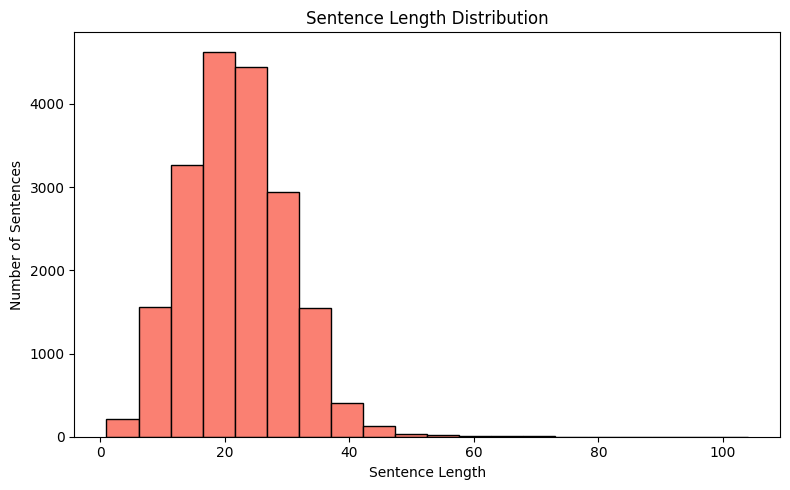

In [ ]:
sentence_lengths = [len(s) for s in train_sentences]

plt.figure(figsize=(8, 5))
plt.hist(sentence_lengths, bins=20, color="salmon", edgecolor='black')
plt.title("Sentence Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

# **Handling Imbalance (Class Weighting)**

In [ ]:
# Compute class weights

from sklearn.utils.class_weight import compute_class_weight

# Exclude PAD index
labels = list(tag2idx.values())
labels.remove(tag2idx['PAD'])

# Flatten labels and mask out padding
flat_labels = [tag2idx[t] for seq in train_tags for t in seq if tag2idx[t] != tag2idx['PAD']]

# Convert labels to a NumPy array
labels = np.array(labels)

# Compute Weights
class_weights = compute_class_weight(class_weight='balanced', classes=labels, y=flat_labels)
class_weights_dict = {i: w for i, w in zip(labels, class_weights)}

# # Flatten labels and mask out padding
# flat_labels = [np.argmax(label) for row in y_train for label in row if np.argmax(label) != tag2idx['PAD']]

# class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(flat_labels), y=flat_labels)
# class_weights_dict = {i: w for i, w in enumerate(class_weights)}

In [ ]:
# Create sample weights matrix

# For each token, assign the weight of its class
sample_weights = np.array([
    [class_weights_dict.get(tag, 1.0) for tag in row] # Get the index of the class using np.argmax
    for row in y_train
])

# **Model Building**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout, TimeDistributed, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import warnings

warnings.filterwarnings('ignore')

In [ ]:
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove.6B.zip

In [ ]:
# y_train = np.argmax(y_train, axis=-1)
# y_test = np.argmax(y_test, axis=-1)
# embeddings_index = {}

# with open('glove.6B.300d.txt', encoding='utf8') as f:
#     for line in f:
#         values = line.split()
#         word = values[0]
#         vector = np.asarray(values[1:], dtype='float32')
#         embeddings_index[word] = vector

In [ ]:
# embedding_dim = 300
# embedding_matrix = np.zeros((len(word2idx), embedding_dim))

# for word, i in word2idx.items():
#     embedding_vector = embeddings_index.get(word)
#     if embedding_vector is not None:
#         embedding_matrix[i-1] = embedding_vector

In [ ]:
# Common Parameters
vocab_size = len(word2idx)
tag_size = len(tag2idx)
embedding_dim = 128
input_length = max_len
hidden_units = 64
batch_size = 32
epochs = 15
dropout_rate = 0.5

In [ ]:
def build_model(model_name='RNN'):
    model = Sequential()
    # model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=input_length))
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length))

    if model_name == 'RNN':
        model.add(SimpleRNN(units=hidden_units, return_sequences=True, dropout=dropout_rate, recurrent_dropout=0.1, kernel_regularizer=l2(0.01)))
    elif model_name == 'LSTM':
        model.add(LSTM(units=hidden_units, return_sequences=True, dropout=dropout_rate, recurrent_dropout=0.1, kernel_regularizer=l2(0.01)))
    elif model_name == 'GRU':
        model.add(GRU(units=hidden_units, return_sequences=True, dropout=dropout_rate, recurrent_dropout=0.1, kernel_regularizer=l2(0.01)))
    elif model_name == 'BiLSTM':
        model.add(Bidirectional(LSTM(units=hidden_units, return_sequences=True, dropout=dropout_rate, recurrent_dropout=0.1, kernel_regularizer=l2(0.01))))

    #model.add(Dropout(dropout_rate))
    model.add(TimeDistributed(Dense(tag_size, activation='softmax')))
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
models = {
    'RNN': build_model('RNN'),
    'LSTM': build_model('LSTM'),
    'GRU': build_model('GRU'),
    'BiLSTM': build_model('BiLSTM')
}

# **Model Training and Evaluation**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, tag2idx, epochs=epochs, batch_size=batch_size):
    print(f"\n--- {model_name} ---")
    model(X_train[:1])
    model.summary()

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    #mc = ModelCheckpoint(f'best_model_{model_name.lower()}.h5', save_best_only=True, verbose=1)

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # Use the validation set explicitly
        sample_weight=sample_weights[:len(X_train)],  # Adjust sample weights for training data
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping]
    )

    # Plot accuracy & loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.show()

    # Predict and evaluate
    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    y_true_labels = y_test

    idx2tag = {i: t for t, i in tag2idx.items()}
    y_pred_flat, y_true_flat = [], []

    for i in range(len(y_true_labels)):
        for j in range(len(y_true_labels[i])):
            if y_true_labels[i][j] != tag2idx['PAD']:
                y_pred_flat.append(idx2tag[y_pred_labels[i][j]])
                y_true_flat.append(idx2tag[y_true_labels[i][j]])

    # Metrics
    acc = accuracy_score(y_true_flat, y_pred_flat)
    f1_macro = f1_score(y_true_flat, y_pred_flat, average='macro')
    f1_weighted = f1_score(y_true_flat, y_pred_flat, average='weighted')
    report = classification_report(y_true_flat, y_pred_flat, digits=4)
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=list(tag2idx.keys()))

    print("Accuracy:", acc)
    print("F1 Score (macro):", f1_macro)
    print("F1 Score (weighted):", f1_weighted)
    print("\nClassification Report:\n", report)
    #print("\nConfusion Matrix:\n", cm)

    return {
        'model': model,
        'history': history,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'report': report,
        'confusion_matrix': cm
    }


--- RNN ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 104, 128)          │     2,931,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (1, 104, 64)           │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (1, 104, 18)           │         1,170 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945,362 (11.24 MB)

 Trainable params: 2,945,362 (11.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.7876 - loss: 1.3193 - val_accuracy: 0.8049 - val_loss: 0.6473
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 80s 95ms/step - accuracy: 0.8039 - loss: 0.6094 - val_accuracy: 0.8044 - val_loss: 0.6125
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.8034 - loss: 0.5519 - val_accuracy: 0.8130 - val_loss: 0.5997
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.8122 - loss: 0.4941 - val_accuracy: 0.8300 - val_loss: 0.5600
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.8285 - loss: 0.4033 - val_accuracy: 0.8431 - val_loss: 0.5292
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.8366 - loss: 0.3331 - val_accuracy: 0.8450 - val_loss: 0.5260
Epoch 7/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.8471 - loss: 0.2963 - val_accuracy: 0.8824 - val_loss: 0.4610
Epoch 8/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.8717 - loss: 0.2633 - 

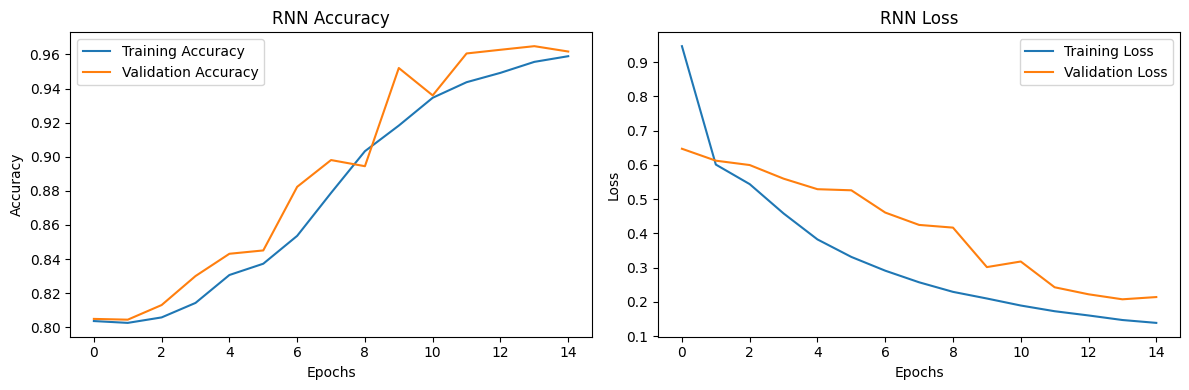

150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
Accuracy: 0.837432485025677
F1 Score (macro): 0.3676669741643854
F1 Score (weighted): 0.8701020811361487

Classification Report:
               precision    recall  f1-score   support

       B-art     0.0075    0.1316    0.0142        38
       B-eve     0.0647    0.5000    0.1146        48
       B-geo     0.7303    0.7739    0.7515      3720
       B-gpe     0.9293    0.8837    0.9059      1651
       B-nat     0.0602    0.5556    0.1087        18
       B-org     0.5146    0.6200    0.5624      1908
       B-per     0.6385    0.7522    0.6907      1731
       B-tim     0.5233    0.8708    0.6537      2051
       I-art     0.0065    0.1053    0.0122        19
       I-eve     0.0945    0.5278    0.1603        36
       I-geo     0.2051    0.6796    0.3151       796
       I-gpe     0.0114    0.3929    0.0221        28
       I-nat     0.0270    0.2857    0.0494         7
       I-org     0.3262    0.6219    0.4280      1629
       I-per     

In [ ]:
rnn_results = train_and_evaluate_model(models['RNN'], "RNN", X_train, y_train, X_val, y_val, X_test, y_test, tag2idx)


--- LSTM ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (1, 104, 128)          │     2,931,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (1, 104, 64)           │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (1, 104, 18)           │         1,170 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,947,256 (34.13 MB)

 Trainable params: 2,982,418 (11.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,964,838 (22.75 MB)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 106s 196ms/step - accuracy: 0.9522 - loss: 0.1606 - val_accuracy: 0.9496 - val_loss: 0.2238
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 141s 194ms/step - accuracy: 0.9533 - loss: 0.1416 - val_accuracy: 0.9547 - val_loss: 0.2039
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 105s 195ms/step - accuracy: 0.9547 - loss: 0.1379 - val_accuracy: 0.9538 - val_loss: 0.2060
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 141s 194ms/step - accuracy: 0.9573 - loss: 0.1355 - val_accuracy: 0.9487 - val_loss: 0.2151
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 106s 196ms/step - accuracy: 0.9600 - loss: 0.1262 - val_accuracy: 0.9628 - val_loss: 0.1705
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 141s 194ms/step - accuracy: 0.9610 - loss: 0.1242 - val_accuracy: 0.9572 - val_loss: 0.1852
Epoch 7/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 141s 193ms/step - accuracy: 0.9627 - loss: 0.1175 - val_accuracy: 0.9614 - val_loss: 0.1702
Epoch 8/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 147s 202ms/step - accuracy: 0.9641 -

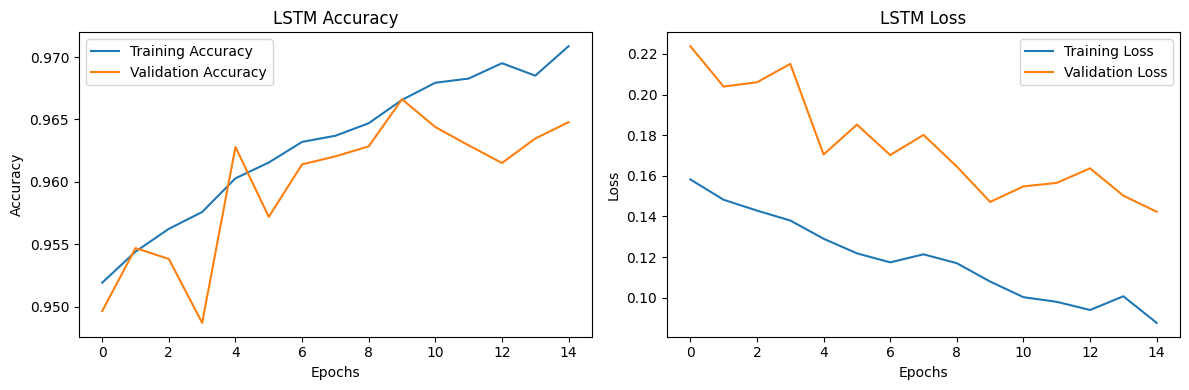

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step
Accuracy: 0.8390461997019374
F1 Score (macro): 0.3759221169622309
F1 Score (weighted): 0.8717621240223176

Classification Report:
               precision    recall  f1-score   support

       B-art     0.0059    0.2632    0.0116        38
       B-eve     0.0441    0.4792    0.0808        48
       B-geo     0.7321    0.7465    0.7393      3720
       B-gpe     0.8893    0.8758    0.8825      1651
       B-nat     0.0566    0.5000    0.1017        18
       B-org     0.3543    0.6504    0.4587      1908
       B-per     0.7425    0.7527    0.7476      1731
       B-tim     0.4890    0.8693    0.6259      2051
       I-art     0.0074    0.1053    0.0138        19
       I-eve     0.0918    0.2500    0.1343        36
       I-geo     0.3286    0.7236    0.4519       796
       I-gpe     0.0385    0.2857    0.0678        28
       I-nat     0.0571    0.2857    0.0952         7
       I-org     0.4444    0.6642    0.5325      1629
       I-per    

In [ ]:
lstm_results = train_and_evaluate_model(models['LSTM'], "LSTM", X_train, y_train, X_val, y_val, X_test, y_test, tag2idx)


--- GRU ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (1, 104, 128)          │     2,931,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (1, 104, 64)           │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (1, 104, 18)           │         1,170 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,970,258 (11.33 MB)

 Trainable params: 2,970,258 (11.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 124s 204ms/step - accuracy: 0.8162 - loss: 1.4579 - val_accuracy: 0.8108 - val_loss: 0.5964
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 140s 201ms/step - accuracy: 0.8099 - loss: 0.5531 - val_accuracy: 0.8645 - val_loss: 0.4689
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 109s 202ms/step - accuracy: 0.8740 - loss: 0.4581 - val_accuracy: 0.9335 - val_loss: 0.3636
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 108s 199ms/step - accuracy: 0.9337 - loss: 0.3242 - val_accuracy: 0.9453 - val_loss: 0.3000
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 140s 196ms/step - accuracy: 0.9492 - loss: 0.2855 - val_accuracy: 0.9574 - val_loss: 0.2459
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 141s 195ms/step - accuracy: 0.9586 - loss: 0.2463 - val_accuracy: 0.9517 - val_loss: 0.2437
Epoch 7/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 107s 198ms/step - accuracy: 0.9608 - loss: 0.2141 - val_accuracy: 0.9578 - val_loss: 0.2126
Epoch 8/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 141s 196ms/step - accuracy: 0.9644 -

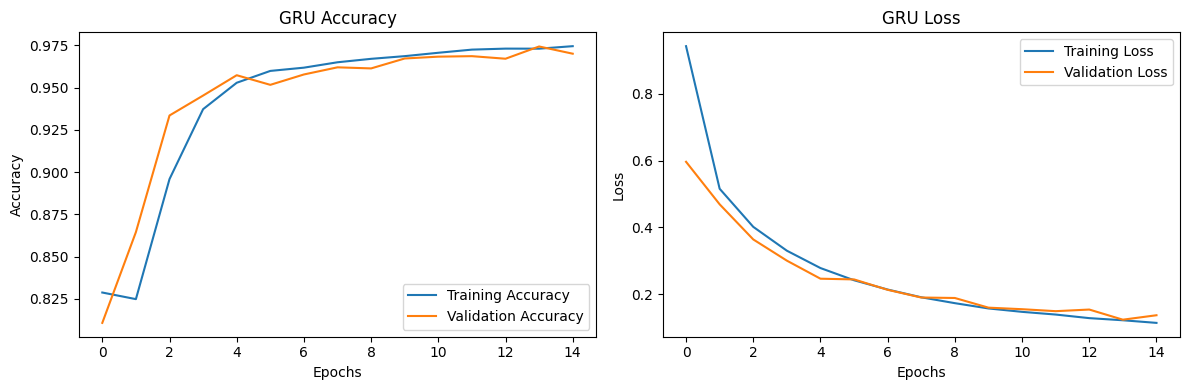

150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step
Accuracy: 0.8855591521353242
F1 Score (macro): 0.4110179956325979
F1 Score (weighted): 0.9034554979693211

Classification Report:
               precision    recall  f1-score   support

       B-art     0.0084    0.1053    0.0156        38
       B-eve     0.1033    0.4583    0.1686        48
       B-geo     0.7839    0.7667    0.7752      3720
       B-gpe     0.9242    0.8789    0.9010      1651
       B-nat     0.1176    0.6667    0.2000        18
       B-org     0.3515    0.6452    0.4551      1908
       B-per     0.6811    0.7811    0.7277      1731
       B-tim     0.5659    0.8645    0.6840      2051
       I-art     0.0000    0.0000    0.0000        19
       I-eve     0.0962    0.4167    0.1562        36
       I-geo     0.4110    0.6759    0.5112       796
       I-gpe     0.0363    0.4286    0.0669        28
       I-nat     0.0600    0.4286    0.1053         7
       I-org     0.5219    0.6354    0.5731      1629
       I-per    

In [ ]:
gru_results = train_and_evaluate_model(models['GRU'], "GRU", X_train, y_train, X_val, y_val, X_test, y_test, tag2idx)


--- BiLSTM ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (1, 104, 128)          │     2,931,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (1, 104, 128)          │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (1, 104, 18)           │         2,322 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,098,936 (34.71 MB)

 Trainable params: 3,032,978 (11.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,065,958 (23.14 MB)

Epoch 1/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 206s 382ms/step - accuracy: 0.7973 - loss: 0.6173 - val_accuracy: 0.8047 - val_loss: 0.6033
Epoch 2/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 290s 433ms/step - accuracy: 0.8044 - loss: 0.5318 - val_accuracy: 0.8229 - val_loss: 0.5571
Epoch 3/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 233s 380ms/step - accuracy: 0.8353 - loss: 0.4769 - val_accuracy: 0.8559 - val_loss: 0.5060
Epoch 4/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 253s 363ms/step - accuracy: 0.8589 - loss: 0.4095 - val_accuracy: 0.8651 - val_loss: 0.4663
Epoch 5/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 195s 360ms/step - accuracy: 0.8678 - loss: 0.3841 - val_accuracy: 0.8751 - val_loss: 0.4351
Epoch 6/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 205s 366ms/step - accuracy: 0.8762 - loss: 0.3565 - val_accuracy: 0.8804 - val_loss: 0.4041
Epoch 7/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 201s 365ms/step - accuracy: 0.8872 - loss: 0.3085 - val_accuracy: 0.8805 - val_loss: 0.4016
Epoch 8/15
540/540 ━━━━━━━━━━━━━━━━━━━━ 204s 368ms/step - accuracy: 0.8916 -

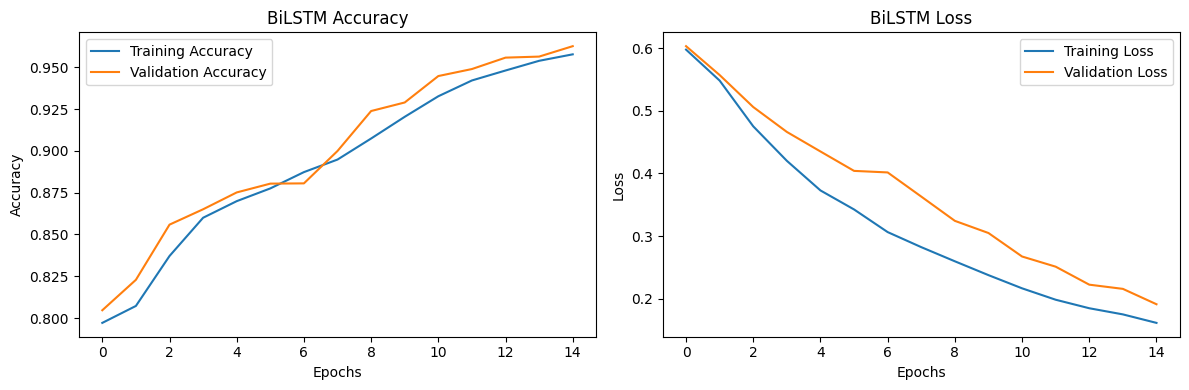

150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step
Accuracy: 0.8275698406219446
F1 Score (macro): 0.36040321165596834
F1 Score (weighted): 0.8582783688740735

Classification Report:
               precision    recall  f1-score   support

       B-art     0.0041    0.1579    0.0080        38
       B-eve     0.0612    0.3542    0.1043        48
       B-geo     0.5281    0.7565    0.6219      3720
       B-gpe     0.8367    0.8625    0.8494      1651
       B-nat     0.1143    0.6667    0.1951        18
       B-org     0.3584    0.6268    0.4561      1908
       B-per     0.6771    0.7377    0.7061      1731
       B-tim     0.5062    0.8820    0.6432      2051
       I-art     0.0074    0.1053    0.0138        19
       I-eve     0.0303    0.0833    0.0444        36
       I-geo     0.2529    0.7236    0.3748       796
       I-gpe     0.0280    0.3214    0.0514        28
       I-nat     0.0469    0.4286    0.0845         7
       I-org     0.4301    0.6237    0.5091      1629
       I-per  

In [ ]:
bilstm_results = train_and_evaluate_model(models['BiLSTM'], "BiLSTM", X_train, y_train, X_val, y_val, X_test, y_test, tag2idx)

In [ ]:
all_results = [rnn_results, lstm_results, gru_results, bilstm_results]
model_names = ["RNN", "LSTM", "GRU", "BiLSTM"]

In [ ]:
summary_data = {
    "Model": model_names,
    "Accuracy": [r['accuracy'] for r in all_results],
    "F1 Macro": [r['f1_macro'] for r in all_results],
    "F1 Weighted": [r['f1_weighted'] for r in all_results]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df)

    Model  Accuracy  F1 Macro  F1 Weighted
0     RNN  0.837432  0.367667     0.870102
1    LSTM  0.839046  0.375922     0.871762
2     GRU  0.885559  0.411018     0.903455
3  BiLSTM  0.827570  0.360403     0.858278


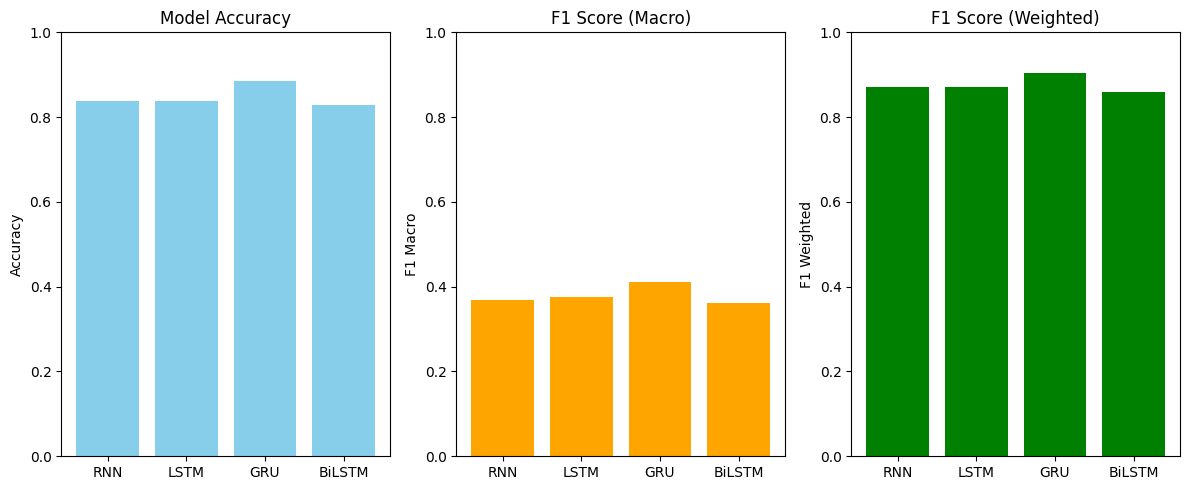

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 3, 1)
plt.bar(model_names, summary_df["Accuracy"], color='skyblue')
plt.title("Model Accuracy")
plt.ylim(0, 1)
plt.ylabel("Accuracy")

# F1 Macro
plt.subplot(1, 3, 2)
plt.bar(model_names, summary_df["F1 Macro"], color='orange')
plt.title("F1 Score (Macro)")
plt.ylim(0, 1)
plt.ylabel("F1 Macro")

# F1 Weighted
plt.subplot(1, 3, 3)
plt.bar(model_names, summary_df["F1 Weighted"], color='green')
plt.title("F1 Score (Weighted)")
plt.ylim(0, 1)
plt.ylabel("F1 Weighted")

plt.tight_layout()
plt.show()

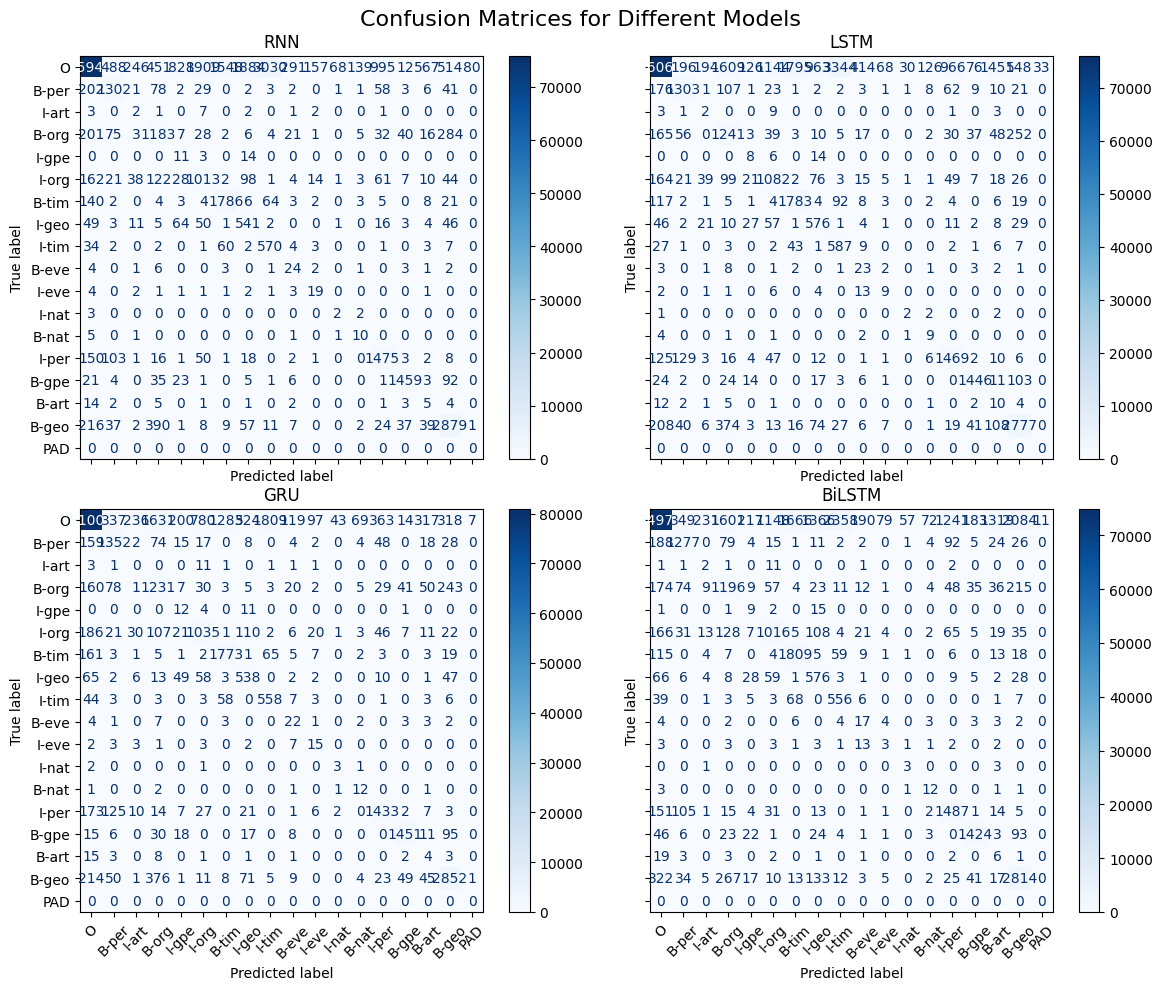

In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle("Confusion Matrices for Different Models", fontsize=16)

# Flatten axes for easier iteration
axes = axes.flatten()

for i, res in enumerate(all_results):
    cm = res['confusion_matrix']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(tag2idx.keys()))
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')  # Plot on the current subplot
    axes[i].set_title(model_names[i])  # Set subplot title
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()  # Adjust layout for a tight fit
plt.show()

In [ ]:
for i, res in enumerate(all_results):
    print(f"\n--- Classification Report for {model_names[i]} ---")
    print(res['report'])


--- Classification Report for RNN ---
              precision    recall  f1-score   support

       B-art     0.0075    0.1316    0.0142        38
       B-eve     0.0647    0.5000    0.1146        48
       B-geo     0.7303    0.7739    0.7515      3720
       B-gpe     0.9293    0.8837    0.9059      1651
       B-nat     0.0602    0.5556    0.1087        18
       B-org     0.5146    0.6200    0.5624      1908
       B-per     0.6385    0.7522    0.6907      1731
       B-tim     0.5233    0.8708    0.6537      2051
       I-art     0.0065    0.1053    0.0122        19
       I-eve     0.0945    0.5278    0.1603        36
       I-geo     0.2051    0.6796    0.3151       796
       I-gpe     0.0114    0.3929    0.0221        28
       I-nat     0.0270    0.2857    0.0494         7
       I-org     0.3262    0.6219    0.4280      1629
       I-per     0.5524    0.8056    0.6554      1831
       I-tim     0.1546    0.8273    0.2605       689
           O     0.9843    0.8519    0.913